# 1.2. Баллистика в 2D — 🟢 + 🟡

Состояние $y=(x,z,v_x,v_z)$, ось $z$ направлена вверх. Во всех опытах $m=1$ кг,
$g=9.81$ м/с², $v_0=20$ м/с, старт и приземление на $z=0$.
Сначала проверяем Эйлера и RK4 на линейном сопротивлении, затем исследуем
$\dot{\mathbf v}=(0,-g)-k|\mathbf v|\mathbf v$; здесь $k$ имеет размерность м⁻¹.
Сила сопротивления равна $-mk|\mathbf v|\mathbf v$.

Все ячейки самостоятельного ноутбука выполняются последовательно. Анимации
встроены в результаты и дополнительно сохраняются в `animations/`.


In [1]:
import time
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML, Markdown
from IPython import get_ipython
from scipy.optimize import brentq

get_ipython().run_line_magic('matplotlib', 'inline')
started = time.perf_counter()
plt.rcParams.update({'figure.dpi': 90, 'font.size': 10,
                     'axes.grid': True, 'animation.embed_limit': 50})
COLORS = plt.cm.viridis(np.linspace(0.08, 0.92, 10))

def step(rhs, state, h, method='RK4'):
    """Явный Эйлер или классический RK4 для автономной системы."""
    k1 = rhs(state)
    if method == 'Euler':
        return state + h*k1
    if method != 'RK4':
        raise ValueError(method)
    k2 = rhs(state + h*k1/2)
    k3 = rhs(state + h*k2/2)
    k4 = rhs(state + h*k3)
    return state + h*(k1 + 2*k2 + 2*k3 + k4)/6

def integrate(rhs, initial, duration, h, method='RK4'):
    # Последний момент точно равен duration; фактический шаг не больше h.
    n = int(np.ceil(duration/h))
    t = np.linspace(0, duration, n+1)
    y = np.empty((n+1, len(initial)))
    y[0] = initial
    for j in range(n):
        y[j+1] = step(rhs, y[j], t[j+1]-t[j], method)
    return t, y

def sample(t, y, times):
    """Интерполяция только для кадров; ошибки считаются на расчётной сетке."""
    return np.column_stack([np.interp(times, t, y[:, j]) for j in range(y.shape[1])])

def table(headers, rows):
    escaped = lambda values: [str(value).replace('|', '&#124;') for value in values]
    display(Markdown('| ' + ' | '.join(escaped(headers)) + ' |\n| ' +
                     ' | '.join(['---']*len(headers)) + ' |\n' +
                     '\n'.join('| ' + ' | '.join(escaped(row)) + ' |' for row in rows)))

def show_animation(fig, update, frames, filename):
    # Кадры встроены: работают без ffmpeg, сети и дополнительных виджетов.
    movie = FuncAnimation(fig, update, frames=frames, interval=70, blit=False)
    html = movie.to_jshtml(default_mode='once')
    # Matplotlib использует внешний шрифт для значков; заменяем локальным текстом.
    html = re.sub(r'<link\s+rel="stylesheet"\s+href="[^"]+">', '', html)
    icons = {'fa-minus': '−', 'fa-plus': '+', 'fa-fast-backward': '⏮',
             'fa-backward': '◀|', 'fa-step-backward': '|◀', 'fa-play': '▶',
             'fa-play fa-flip-horizontal': '◀', 'fa-step-forward': '▶|', 'fa-pause': 'Ⅱ',
             'fa-stop': '■', 'fa-forward': '|▶', 'fa-fast-forward': '⏭',
             'fa-refresh': '↻'}
    html = re.sub(r'<i class="fa ([^"]+)"[^>]*></i>',
                  lambda match: icons.get(match[1], match[1].removeprefix('fa-')), html)
    plt.close(fig)
    out = Path('animations')
    out.mkdir(exist_ok=True)
    (out/filename).write_text('<!doctype html><meta charset="utf-8">' + html, encoding='utf-8')
    display(HTML(html))


In [2]:
g, mass, v0 = 9.81, 1.0, 20.0

def initial(angle):
    a = np.deg2rad(angle)
    return np.array([0., 0., v0*np.cos(a), v0*np.sin(a)])

def linear_rhs(tau):
    return lambda s: np.array([s[2], s[3], -s[2]/tau, -g-s[3]/tau])

def linear_exact(t, angle, tau):
    vx, vz = initial(angle)[2:]
    q = -np.expm1(-np.asarray(t)/tau)
    return np.column_stack([tau*vx*q, tau*(vz+g*tau)*q-g*tau*t,
                            vx*(1-q), (vz+g*tau)*(1-q)-g*tau])

def quadratic_rhs(k):
    def rhs(s):
        speed = np.hypot(s[2], s[3])
        return np.array([s[2], s[3], -k*speed*s[2], -g-k*speed*s[3]])
    return rhs

def flight(angle, k=0., h=.02, method='RK4', rhs=None):
    """Первое возвращение на землю; последний неполный шаг уточняется по z=0."""
    rhs = quadratic_rhs(k) if rhs is None else rhs
    ts, ys = [0.], [initial(angle)]
    for _ in range(int(60/h)+1):
        candidate = step(rhs, ys[-1], h, method)
        if candidate[1] < 0:
            # Для положительного угла пересечение должно быть после подъёма.
            if ys[-1][1] <= 0:
                raise ValueError('Слишком крупный шаг: подъём не разрешён')
            dt = brentq(lambda dt: step(rhs, ys[-1], dt, method)[1], 0, h, xtol=1e-13)
            landing = step(rhs, ys[-1], dt, method)
            assert abs(landing[1]) < 1e-9
            landing[1] = 0.0
            ts.append(ts[-1]+dt); ys.append(landing)
            return np.array(ts), np.array(ys)
        ts.append(ts[-1]+h); ys.append(candidate)
    raise RuntimeError('Не найден момент падения за 60 с')


## 1. Проверка на линейном сопротивлении

Обозначим $q=1-e^{-t/\tau}$. Тогда $x=\tau v_{x0}q$,
$z=\tau(v_{z0}+g\tau)q-g\tau t$, $v_x=v_{x0}e^{-t/\tau}$,
$v_z=(v_{z0}+g\tau)e^{-t/\tau}-g\tau$.

Сравниваем решения до **точного** момента падения при $\tau=2$ с, $\alpha=45°$.
Ошибка — максимум евклидовой ошибки положения на сетке. Энергия
$E=K+U=m|v|^2/2+mgz$ должна убывать: $dE/dt=-m|v|^2/\tau$.


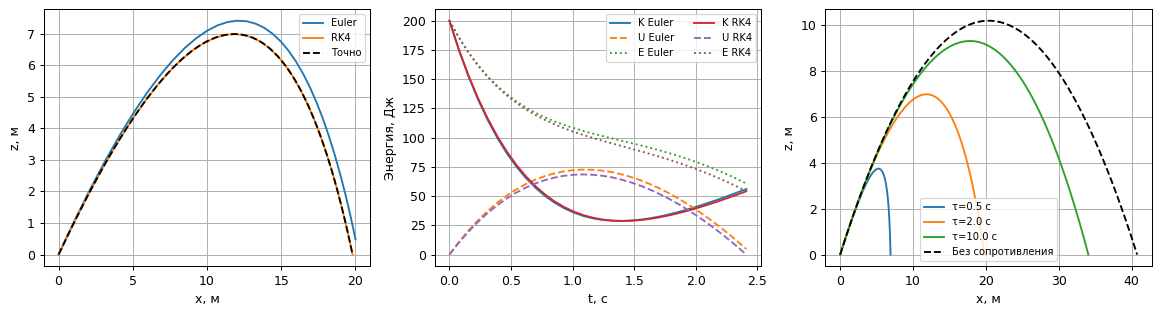

| Метод | Фактический шаг, с | max ошибка положения, м |
| --- | --- | --- |
| Euler | 0.15065 | 1.048e+00 |
| Euler | 0.07775 | 5.321e-01 |
| Euler | 0.03951 | 2.683e-01 |
| Euler | 0.01992 | 1.347e-01 |
| RK4 | 0.15065 | 7.692e-06 |
| RK4 | 0.07775 | 5.296e-07 |
| RK4 | 0.03951 | 3.476e-08 |
| RK4 | 0.01992 | 2.227e-09 |

In [3]:
tau, angle = 2., 45.
tf = brentq(lambda t: linear_exact(np.array([t]), angle, tau)[0, 1], .01, 10)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
rows, errors = [], {}
for method in ['Euler', 'RK4']:
    errors[method] = []
    for h in [.16, .08, .04, .02]:
        t, y = integrate(linear_rhs(tau), initial(angle), tf, h, method)
        exact = linear_exact(t, angle, tau)
        err = np.max(np.linalg.norm(y[:, :2]-exact[:, :2], axis=1))
        errors[method].append(err)
        rows.append([method, f'{t[1]:.5f}', f'{err:.3e}'])
    t, y = integrate(linear_rhs(tau), initial(angle), tf, .08, method)
    ax[0].plot(y[:, 0], y[:, 1], label=method)
    K, U = mass*np.sum(y[:, 2:]**2, axis=1)/2, mass*g*y[:, 1]
    for vals, label, ls in [(K, 'K', '-'), (U, 'U', '--'), (K+U, 'E', ':')]:
        ax[1].plot(t, vals, ls, label=f'{label} {method}')
exact = linear_exact(np.linspace(0, tf, 400), angle, tau)
ax[0].plot(exact[:, 0], exact[:, 1], 'k--', label='Точно')
for drag_tau in [.5, 2., 10.]:
    ti, yi = flight(angle, h=.02, rhs=linear_rhs(drag_tau))
    ax[2].plot(yi[:, 0], yi[:, 1], label=f'τ={drag_tau} с')
ti, yi = flight(angle, k=0)
ax[2].plot(yi[:, 0], yi[:, 1], 'k--', label='Без сопротивления')
for a in [ax[0], ax[2]]:
    a.set(xlabel='x, м', ylabel='z, м'); a.legend(fontsize=8)
ax[1].set(xlabel='t, с', ylabel='Энергия, Дж'); ax[1].legend(fontsize=8, ncol=2)
fig.tight_layout(); display(fig); plt.close(fig)
table(['Метод', 'Фактический шаг, с', 'max ошибка положения, м'], rows)
assert errors['RK4'][-2]/errors['RK4'][-1] > 12
assert errors['Euler'][-1] < errors['Euler'][0]


## 2. Квадратичное сопротивление и максимум дальности

Перебираем углы от 5° до 85° с шагом 1°. Окрестность лучшего угла уточняем
перебором с шагом 0.05°. Это два конечных перебора, не непрерывная оптимизация.
При $k=0$ эталон $R=v_0^2\sin(2\alpha)/g$ даёт максимум при 45°.

Момент приземления ищется внутри последнего шага с помощью повторного шага RK4
длиной $\delta t$ и скалярного поиска корня высоты. Простое сохранение первого
подземного узла внесло бы дополнительную ошибку порядка шага.


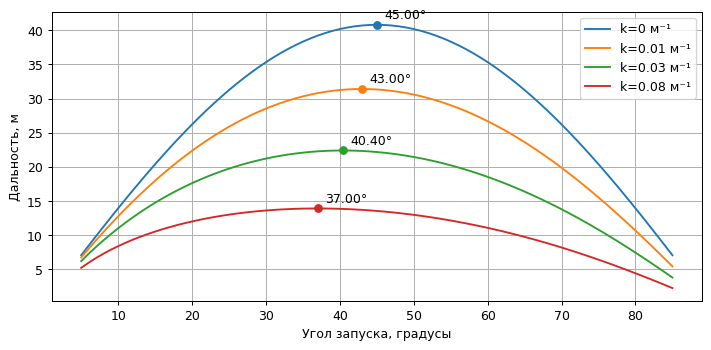

| k, м⁻¹ | Лучший угол сетки, ° | Дальность, м |
| --- | --- | --- |
| 0.0 | 45.00 | 40.77472 |
| 0.01 | 43.00 | 31.39146 |
| 0.03 | 40.40 | 22.39867 |
| 0.08 | 37.00 | 13.92305 |

In [4]:
angles = np.arange(5., 86.)
ks = [0., .01, .03, .08]

def scan(k, h):
    ranges = np.array([flight(a, k, h)[1][-1, 0] for a in angles])
    best = angles[np.argmax(ranges)]
    fine = np.arange(best-1, best+1.0001, .05)
    rf = np.array([flight(a, k, h)[1][-1, 0] for a in fine])
    j = np.argmax(rf)
    return ranges, float(fine[j]), float(rf[j])

fig, ax = plt.subplots(figsize=(8, 4))
maxima = {}
for k in ks:
    ranges, optimum, distance = scan(k, .02)
    maxima[k] = (optimum, distance)
    line, = ax.plot(angles, ranges, label=f'k={k:g} м⁻¹')
    ax.plot(optimum, distance, 'o', color=line.get_color())
    ax.annotate(f'{optimum:.2f}°', (optimum, distance), xytext=(6, 5), textcoords='offset points')
ax.set(xlabel='Угол запуска, градусы', ylabel='Дальность, м'); ax.legend()
fig.tight_layout(); display(fig); plt.close(fig)
table(['k, м⁻¹', 'Лучший угол сетки, °', 'Дальность, м'],
      [[k, f'{a:.2f}', f'{r:.5f}'] for k, (a, r) in maxima.items()])
assert abs(maxima[0][0]-45) < 1e-8
for a in [15, 45, 75]:
    tfree, yfree = flight(a, 0, .07)
    assert abs(yfree[-1, 0]-v0**2*np.sin(2*np.deg2rad(a))/g) < 1e-9
    assert abs(tfree[-1]-2*v0*np.sin(np.deg2rad(a))/g) < 1e-10


## 3. Сходимость: не путать шаг времени с шагом перебора углов

Для $k=0.03$ повторим весь поиск при четырёх временных шагах.
Дополнительно сравним дальность **при фиксированном** угле 40° с расчётом
на шаге 0.00125 с. Это численный эталон, не точное решение.
Неизменность лучшего угла сама по себе не доказывает сходимости:
угловая сетка различает только 0.05°.


| h, с | Лучший угол, ° | R_max, м | t_падения при 40°, с | &#124;R_h(40°)−R_ref&#124;, м |
| --- | --- | --- | --- | --- |
| 0.08 | 40.40 | 22.39866698 | 2.194935271 | 5.463e-06 |
| 0.04 | 40.40 | 22.39867208 | 2.194935686 | 3.257e-07 |
| 0.02 | 40.40 | 22.39867239 | 2.194935711 | 1.987e-08 |
| 0.01 | 40.40 | 22.39867240 | 2.194935712 | 1.227e-09 |

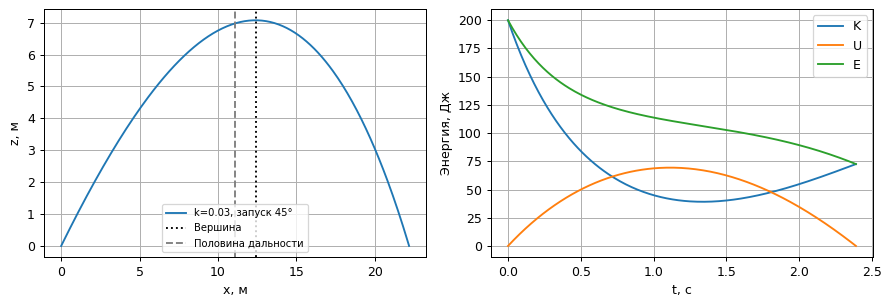

**Ответ:** для исследованных коэффициентов сопротивления оптимальный угол уменьшается от 45° до 37.00°. При k=0.03 и запуске 45° подъём длится 1.115 с, спуск — 1.276 с; вершина находится на 55.9% дальности. Угол падения к горизонту 58.8°, то есть спуск круче подъёма. Горизонтальная скорость падает, поэтому траектория теряет зеркальную симметрию.

In [5]:
k_selected = .03
ref_t, ref_y = flight(40, k_selected, .00125)
rows, range_errors = [], []
for h in [.08, .04, .02, .01]:
    _, opt, distance = scan(k_selected, h)
    ti, yi = flight(40, k_selected, h)
    err = abs(yi[-1, 0]-ref_y[-1, 0])
    range_errors.append(err)
    rows.append([h, f'{opt:.2f}', f'{distance:.8f}', f'{ti[-1]:.9f}', f'{err:.3e}'])
table(['h, с', 'Лучший угол, °', 'R_max, м', 't_падения при 40°, с', '|R_h(40°)−R_ref|, м'], rows)
assert range_errors[-2]/range_errors[-1] > 10

# Асимметрия: уточняем вершину по v_z=0 тем же приёмом.
t, y = flight(45, k_selected, .01)
rhs = quadratic_rhs(k_selected)
j = np.flatnonzero((y[:-1, 3] > 0) & (y[1:, 3] <= 0))[0]
dt = brentq(lambda dt: step(rhs, y[j], dt)[3], 0, t[j+1]-t[j])
apex = step(rhs, y[j], dt)
t_up, t_down = t[j]+dt, t[-1]-t[j]-dt
landing_angle = np.rad2deg(np.arctan2(-y[-1, 3], y[-1, 2]))
K, U = mass*np.sum(y[:, 2:]**2, axis=1)/2, mass*g*y[:, 1]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(y[:, 0], y[:, 1], label='k=0.03, запуск 45°')
ax[0].axvline(apex[0], color='k', ls=':', label='Вершина')
ax[0].axvline(y[-1, 0]/2, color='gray', ls='--', label='Половина дальности')
ax[0].set(xlabel='x, м', ylabel='z, м'); ax[0].legend(fontsize=8)
for vals, label in [(K, 'K'), (U, 'U'), (K+U, 'E')]: ax[1].plot(t, vals, label=label)
ax[1].set(xlabel='t, с', ylabel='Энергия, Дж'); ax[1].legend()
fig.tight_layout(); display(fig); plt.close(fig)
display(Markdown(f'**Ответ:** для исследованных коэффициентов сопротивления оптимальный угол '
                 f'уменьшается от 45° до {maxima[.08][0]:.2f}°. '
                 f'При k=0.03 и запуске 45° подъём длится {t_up:.3f} с, '
                 f'спуск — {t_down:.3f} с; вершина находится на '
                 f'{100*apex[0]/y[-1, 0]:.1f}% дальности. '
                 f'Угол падения к горизонту {landing_angle:.1f}°, то есть спуск круче подъёма. '
                 'Горизонтальная скорость падает, поэтому траектория теряет зеркальную симметрию.'))
assert np.max(np.diff(K+U)) < 1e-7


## 4. Полёт со скоростью и силами

Стрелки имеют разные явно заданные масштабы: 0.12 м рисунка на 1 м/с для скорости,
0.20 м рисунка на 1 Н для сил. Сравнивать длины стрелок скорости и сил физически нельзя.
Гравитация постоянна; сопротивление направлено против скорости.


In [6]:
frames = np.linspace(0, t[-1], 91)
motion = sample(t, y, frames)
fig, ax = plt.subplots(figsize=(8, 3.8), dpi=75)
trail, = ax.plot([], [], color='tab:blue')
body, = ax.plot([], [], 'o', color='black')
arrows = [ax.quiver([0], [0], [0], [0], angles='xy', scale_units='xy', scale=1,
                    color=color, label=label) for color, label in
          [('tab:blue', 'v: 0.12 м / (м/с)'), ('tab:red', 'mg: 0.20 м / Н'), ('tab:green', 'Fсопр: 0.20 м / Н')]]
ax.axhline(0, color='k'); ax.set(xlim=(-4, y[-1, 0]+5), ylim=(-4, y[:, 1].max()+5),
                               aspect='equal', xlabel='x, м', ylabel='z, м')
ax.legend(loc='upper right', fontsize=8); title = ax.set_title(''); fig.tight_layout()
def update(j):
    s = motion[j]; v = s[2:]
    vectors = [.12*v, .20*np.array([0, -mass*g]), -.20*mass*k_selected*np.linalg.norm(v)*v]
    trail.set_data(motion[:j+1, 0], motion[:j+1, 1]); body.set_data([s[0]], [s[1]])
    for arrow, vector in zip(arrows, vectors):
        arrow.set_offsets(s[:2].reshape(1, 2)); arrow.set_UVC([vector[0]], [vector[1]])
    title.set_text(f't = {frames[j]:.2f} с, |v| = {np.linalg.norm(v):.2f} м/с')
show_animation(fig, update, len(frames), '1.2_vectors.html')


## 5. Одновременный запуск: без сопротивления и с ним

Десять углов от 10° до 80°, одна скорость, единая физическая шкала времени
и одинаковые пределы координат на обеих панелях. После падения тело перестаёт
двигаться, в точке падения остаётся крестик. Цвет соответствует углу.


In [7]:
launch_angles = np.linspace(10, 80, 10)
flights = [[flight(a, k, .01) for a in launch_angles] for k in [0, k_selected]]
frames = np.linspace(0, max(ti[-1] for panel in flights for ti, _ in panel), 111)
motions = [[sample(ti, yi, frames) for ti, yi in panel] for panel in flights]
fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=75, sharex=True, sharey=True)
artists = []
for panel, k in zip(ax, [0, k_selected]):
    group = []
    for a, color in zip(launch_angles, COLORS):
        trail, = panel.plot([], [], color=color, lw=1, label=f'{a:.0f}°')
        dot, = panel.plot([], [], 'o', color=color, ms=4)
        mark, = panel.plot([], [], 'x', color=color, ms=7)
        group.append((trail, dot, mark))
    artists.append(group)
    panel.set(title=f'k={k:g} м⁻¹', xlim=(-1, 44), ylim=(-1, 22), aspect='equal', xlabel='x, м')
    panel.axhline(0, color='k')
ax[0].set_ylabel('z, м'); ax[1].legend(ncol=2, fontsize=7, loc='upper right')
title = fig.suptitle(''); fig.tight_layout()
def update(j):
    for p in range(2):
        for i, (trail, dot, mark) in enumerate(artists[p]):
            ti, yi = flights[p][i]; motion = motions[p][i]
            trail.set_data(motion[:j+1, 0], motion[:j+1, 1])
            if frames[j] >= ti[-1]:
                dot.set_data([], []); mark.set_data([yi[-1, 0]], [0])
            else:
                dot.set_data([motion[j, 0]], [motion[j, 1]]); mark.set_data([], [])
    title.set_text(f'Одновременный запуск, t = {frames[j]:.2f} с')
show_animation(fig, update, len(frames), '1.2_ensemble.html')


## Выводы и оценка сложности

- Дальность и оптимальный угол уменьшаются с ростом сопротивления в рассмотренном диапазоне.
- Сопротивление нарушает симметрию: вершина смещается к дальней половине дальности,
  нисходящая ветвь круче, скорость при падении меньше начальной.
- Уточнение момента падения необходимо для осмысленного сравнения временных шагов.
  Точность угла дополнительно ограничивает дискретный перебор.
- Наиболее сложные места: обработка события приземления и остановка отдельных тел
  в общей анимации. Поиск корня здесь нужен лишь внутри уже найденного шага.

**Оценка для студента:** 7–12 часов со знанием Python; 12–18 часов при первом опыте
численного моделирования и анимаций. Это ориентир преподавателю, не результат хронометража.


In [8]:
print(f'Все численные проверки пройдены. Полное выполнение: {time.perf_counter()-started:.1f} с.')


Все численные проверки пройдены. Полное выполнение: 15.5 с.
